<img src='https://upload.wikimedia.org/wikipedia/commons/thumb/a/aa/Logo_DuocUC.svg/2560px-Logo_DuocUC.svg.png' width=50%, height=20%>

<p style="color:yellow"><strong>DATASET: HEART DISEASE UCI</strong></p>

**Descripción:** Este conjunto de datos contiene información médica de pacientes, incluyendo variables como edad, sexo, presión arterial, colesterol, frecuencia cardíaca máxima, entre otros. El objetivo es predecir la presencia o ausencia de enfermedad cardíaca.

**Objetivo: Aplicar las etapas de CRISP-DM utilizando el dataset de enfermedad cardíaca.​**

**Variable Objetivo:** "num"

**0** → No hay enfermedad  
**1, 2, 3, 4** → Sí hay enfermedad, en diferentes niveles de severidad (Cambiarla)

<p style="color:yellow"><strong>VARIABLES</strong></p>

**1. id:** Identificador único para cada paciente. No aporta valor predictivo, se puede eliminar.  
**2. age:** Edad del paciente en años.  
**3. sex:** Sexo del paciente: "Male" o "Female".  
**4. dataset:** Lugar de origen del estudio (Cleveland, VA Long Beach, etc.). Puede usarse como agrupador o eliminarse si no es relevante.   
**5. cp:** Tipo de dolor en el pecho: typical angina, atypical angina, non-anginal, asymptomatic. Variable relevante para predicción.  
**6. trestbps:** Presión arterial en reposo (mm Hg).  
**7. chol:** Nivel de colesterol sérico en sangre (mg/dl).  
**8. fbs:** Azúcar en sangre en ayunas > 120 mg/dl: True (sí) o False (no).  
**9. restecg:** Resultados del electrocardiograma en reposo: normal, st-t abnormality, lv hypertrophy.  
**10. thalach:** Frecuencia cardíaca máxima alcanzada durante una prueba de esfuerzo.  
**11. exang:** Angina inducida por ejercicio: True o False.  
**12. oldpeak:** Depresión del segmento ST (medida de anormalidad en ECG) inducida por ejercicio.  
**13. slope:** Pendiente del segmento ST durante el ejercicio: upsloping, flat, downsloping.  
**14. ca:** Número de vasos principales coloreados por fluoroscopía (0 a 3). Tiene valores nulos.  
**15. thal:** Resultado del test de talio: normal, fixed defect, reversible defect. Tiene valores nulos.  
**16. num:** Variable objetivo

INTEGRANTES

CAMILO GONZALEZ


<p style="color:red"><strong>CARGA DEL DATASET</strong></p>

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


from google.colab import drive
drive.mount('/content/drive')

# Ruta correcta con espacio reemplazado
ruta = "/content/heart_disease_uci.csv"

# Cargar el archivo CSV
df = pd.read_csv(ruta)




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [3]:
# Convertir la variable objetivo 'num' a binaria (0 o 1)
df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

In [4]:
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,1
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [5]:
import pandas as pd
from sklearn.impute import SimpleImputer

# Identificar columnas numéricas y categóricas
numerical_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Imputar valores faltantes en columnas numéricas con la media
numerical_imputer = SimpleImputer(strategy='mean')
df[numerical_cols] = numerical_imputer.fit_transform(df[numerical_cols])

# Imputar valores faltantes en columnas categóricas con la moda
categorical_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = categorical_imputer.fit_transform(df[categorical_cols])

In [6]:
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1.0,63.0,Male,Cleveland,typical angina,145.000000,233.0,True,lv hypertrophy,150.000000,False,2.300000,downsloping,0.000000,fixed defect,0.0
1,2.0,67.0,Male,Cleveland,asymptomatic,160.000000,286.0,False,lv hypertrophy,108.000000,True,1.500000,flat,3.000000,normal,1.0
2,3.0,67.0,Male,Cleveland,asymptomatic,120.000000,229.0,False,lv hypertrophy,129.000000,True,2.600000,flat,2.000000,reversable defect,1.0
3,4.0,37.0,Male,Cleveland,non-anginal,130.000000,250.0,False,normal,187.000000,False,3.500000,downsloping,0.000000,normal,0.0
4,5.0,41.0,Female,Cleveland,atypical angina,130.000000,204.0,False,lv hypertrophy,172.000000,False,1.400000,upsloping,0.000000,normal,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916.0,54.0,Female,VA Long Beach,asymptomatic,127.000000,333.0,True,st-t abnormality,154.000000,False,0.000000,flat,0.676375,normal,1.0
916,917.0,62.0,Male,VA Long Beach,typical angina,132.132404,139.0,False,st-t abnormality,137.545665,False,0.878788,flat,0.676375,normal,0.0
917,918.0,55.0,Male,VA Long Beach,asymptomatic,122.000000,223.0,True,st-t abnormality,100.000000,False,0.000000,flat,0.676375,fixed defect,1.0
918,919.0,58.0,Male,VA Long Beach,asymptomatic,132.132404,385.0,True,lv hypertrophy,137.545665,False,0.878788,flat,0.676375,normal,0.0


In [7]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0


# **PARA ESTE PROYECTO VAMOS A ELEGIR 3 MODELOS DE CLASIFICACION**

## Justificación de la Elección de Modelos de Clasificación

Para abordar el desafío de predecir la presencia o ausencia de enfermedades cardíacas, hemos seleccionado tres modelos de Machine Learning ampliamente reconocidos y eficaces. Nuestra elección busca ofrecer una perspectiva integral, comparando enfoques de modelado que van desde lo más interpretable hasta lo más potente, permitiendo identificar la solución más adecuada para nuestro problema.

### 1. Regresión Logística

* **Descripción:** La Regresión Logística, a pesar de su nombre, es un algoritmo fundamental para problemas de clasificación. Funciona como un "doctor lógico" que analiza cada factor de riesgo (edad, colesterol, presión, etc.) y calcula la probabilidad de que un paciente desarrolle una enfermedad cardíaca. Intenta encontrar una "línea" o "frontera" que mejor separe a los pacientes sanos de los enfermos.
* **Justificación de la Elección:**
    * **Simplicidad e Interpretación:** Es un modelo relativamente sencillo de entender y explicar. Podemos ver cómo cada factor influye en la probabilidad de la enfermedad (por ejemplo, "a mayor colesterol, mayor probabilidad"). Esto es crucial en aplicaciones médicas, donde la transparencia del diagnóstico es importante.
    * **Línea Base Robusta:** Es un excelente punto de partida. Nos permite establecer una "línea base" de rendimiento. Si un modelo más complejo no supera significativamente a la Regresión Logística, podría indicar que los patrones en los datos no son tan complejos o que el modelo más simple es suficiente.
    * **Eficiencia Computacional:** Es rápido de entrenar y predecir, lo que lo hace viable incluso con grandes volúmenes de datos.

### 2. Random Forest

* **Descripción:** El Random Forest  es como tener un "equipo de muchos mini-doctores" (árboles de decisión). Cada mini-doctor hace un diagnóstico de forma independiente basándose en una parte aleatoria de la información y un subconjunto aleatorio de los factores de riesgo. Al final, todos los mini-doctores votan, y el diagnóstico final es el que recibe más votos. Esto ayuda a corregir los errores individuales de cada mini-doctor.
* **Justificación de la Elección:**
    * **Potencia Predictiva:** Es conocido por su alta precisión y capacidad para manejar relaciones complejas y no lineales en los datos. Los factores de riesgo de enfermedades cardíacas a menudo interactúan de maneras no lineales, y el Random Forest es excelente para capturar esto.
    * **Reducción del Sobreajuste:** Al combinar múltiples árboles (que individualmente podrían "memorizar" demasiado los datos de entrenamiento), el Random Forest es muy bueno generalizando a datos nuevos, lo que reduce el riesgo de diagnósticos incorrectos en pacientes no vistos.
    * **Manejo de Características Diversas:** Puede trabajar bien con diferentes tipos de datos (numéricos y categóricos) sin necesidad de transformaciones excesivas.

### 3. SVM

* **Descripción:** Las Máquinas de Vectores de Soporte, o SVM, son como un "doctor muy inteligente" que busca la mejor "frontera" de separación entre los pacientes sanos y los enfermos. No solo busca una línea, sino que encuentra la línea que tiene el mayor "margen" (espacio) entre los dos grupos más cercanos. Si los datos no se pueden separar con una línea recta, el SVM puede usar un truco matemático (llamado "kernel") para proyectar los datos a un espacio donde sí se puedan separar, y luego los vuelve a proyectar al espacio original.
* **Justificación de la Elección:**
    * **Robustez y Precisión en Datos Complejos:** SVM es particularmente efectivo en conjuntos de datos donde la separación entre clases no es obvia o lineal. Su capacidad para usar "kernels" le permite modelar relaciones intrincadas y no lineales, lo cual es muy relevante en datos médicos complejos.
    * **Eficacia con Dimensiones Altas:** Puede manejar eficientemente conjuntos de datos con muchas características, lo que es común en el ámbito de la salud.
    * **Generalización Sólida:** Al enfocarse en maximizar el margen de separación, SVM tiende a generalizar bien a nuevos datos, lo que es crucial para la confiabilidad de un diagnóstico.

### Conclusión de la Elección:

La selección de estos tres modelos nos permite realizar una **comparación equilibrada** entre diferentes paradigmas de aprendizaje automático: un modelo lineal (Regresión Logística), un método de conjunto basado en árboles (Random Forest) y un clasificador basado en márgenes (SVM). Esta diversidad nos ayuda a comprender mejor las relaciones en nuestros datos y a identificar cuál de estos "doctores" virtuales es el más competente para predecir con precisión las enfermedades cardíacas, considerando tanto su rendimiento como sus características intrínsecas.

<p style="color:red"><strong>CRISP DM - 4 ETAPA - MODELADO</strong></p>

<p style="color:red"><strong>MODELO 1 - </strong></p> de clasificacion

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# 2. Separar la variable objetivo y las características
# ¡Asumiendo que 'target' es la variable objetivo! Reemplaza si es diferente.
X = df.drop('num', axis=1)
y = df['num']

# 3. Identificar columnas numéricas y categóricas
numerical_features = X.select_dtypes(include=['number']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# 4. Crear preprocesadores
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 5. Crear el preprocesador general
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 6. Dividir los datos en conjuntos de entrenamiento y prueba (70/30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 7. Entrenar el modelo de Regresión Logística
logistic_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                  ('classifier', LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced'))])
logistic_pipeline.fit(X_train, y_train)
logistic_predictions = logistic_pipeline.predict(X_test)

### Justificación de la División de Datos (70/30)

Para evaluar la capacidad de nuestros modelos de clasificación para generalizar a nuevos pacientes (es decir, datos que no vieron durante su "entrenamiento"), es fundamental dividir nuestro conjunto de datos en dos partes:

1.  **Conjunto de Entrenamiento (70% de los datos):** Esta porción de los datos se utiliza para que los modelos "aprendan" los patrones y relaciones entre las características de los pacientes (edad, colesterol, etc.) y si tienen o no una enfermedad cardíaca. Es como la fase de estudio donde el modelo absorbe el conocimiento.

2.  **Conjunto de Prueba (30% de los datos):** Una vez que los modelos han sido entrenados, se evalúan exclusivamente con esta porción de los datos. El conjunto de prueba contiene información de pacientes que los modelos nunca vieron durante su entrenamiento. Esto nos permite simular cómo se comportarían los modelos en el mundo real, con datos nuevos y desconocidos.

**¿Por qué una división 70/30?**

Elegimos dividir los datos en un 70% para entrenamiento y un 30% para prueba por las siguientes razones:

* **Equilibrio entre Aprendizaje y Evaluación:** Una proporción de 70/30 es una práctica común y bien aceptada en Machine Learning.
    * Destinar el **70% al entrenamiento** proporciona a nuestros modelos una cantidad sustancial de datos para aprender patrones significativos y reducir el riesgo de "memorizar" demasiado (sobreajuste) si el conjunto de entrenamiento fuera demasiado pequeño. Es suficiente para que los modelos entiendan las complejidades del problema.
    * Reservar el **30% para la prueba** asegura que tengamos una muestra representativa y lo suficientemente grande de datos no vistos para una evaluación confiable. Un conjunto de prueba demasiado pequeño podría darnos una evaluación engañosa de la capacidad real del modelo.

* **Adecuación al Tamaño del Dataset:** Dado el tamaño típico de los datasets de enfermedades cardíacas (generalmente de cientos a pocos miles de registros), 70/30 ofrece un buen balance. Para datasets muy grandes, una división como 80/20 podría ser suficiente, mientras que para datasets muy pequeños, a veces se requieren técnicas más avanzadas como la validación cruzada. Sin embargo, para este análisis, 70/30 es una elección robusta.

* **Consistencia y Estándar:** Esta división es un estándar de facto en muchas aplicaciones de Machine Learning, lo que facilita la comparación de nuestros resultados con otros estudios y asegura una metodología reconocida.

Al realizar esta separación, garantizamos que la evaluación de nuestros modelos sea imparcial y que los resultados reflejen su verdadera capacidad para diagnosticar enfermedades cardíacas en pacientes futuros.

<p style="color:red"><strong>MODELO 2 - </strong></p> de clasificacion


In [9]:
# 8. Entrenar el modelo de Random Forest
forest_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                ('classifier', RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced'))])
forest_pipeline.fit(X_train, y_train)
forest_predictions = forest_pipeline.predict(X_test)

<p style="color:red"><strong>MODELO 3 - </strong></p> de clasificacion , aplican y evaluan, comparan

In [10]:
# 9. Entrenar el modelo de SVM
print("Entrenando Máquina de Vectores de Soporte (SVM)...")
svm_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                             ('classifier', SVC(random_state=42, kernel='rbf', class_weight='balanced'))])
svm_pipeline.fit(X_train, y_train)
svm_predictions = svm_pipeline.predict(X_test)

Entrenando Máquina de Vectores de Soporte (SVM)...


# Resultados

In [11]:
# 9. Evaluar y comparar los modelos

print("Resultados de la Regresión Logística:")
print("Precisión:", accuracy_score(y_test, logistic_predictions))
print("Reporte de Clasificación:\n", classification_report(y_test, logistic_predictions))
cm_logistic = confusion_matrix(y_test, logistic_predictions)

print("\nResultados del Bosque Aleatorio:")
print("Precisión:", accuracy_score(y_test, forest_predictions))
print("Reporte de Clasificación:\n", classification_report(y_test, forest_predictions))
cm_forest = confusion_matrix(y_test, forest_predictions)


print("Resultados de la Máquina de Vectores de Soporte (SVM):")
print(f"Precisión (Accuracy): {accuracy_score(y_test, svm_predictions):.4f}")
print("Reporte de Clasificación:\n", classification_report(y_test, svm_predictions))
cm_svm = confusion_matrix(y_test, svm_predictions)

Resultados de la Regresión Logística:
Precisión: 0.8333333333333334
Reporte de Clasificación:
               precision    recall  f1-score   support

         0.0       0.78      0.85      0.82       120
         1.0       0.88      0.82      0.85       156

    accuracy                           0.83       276
   macro avg       0.83      0.84      0.83       276
weighted avg       0.84      0.83      0.83       276


Resultados del Bosque Aleatorio:
Precisión: 0.8804347826086957
Reporte de Clasificación:
               precision    recall  f1-score   support

         0.0       0.87      0.86      0.86       120
         1.0       0.89      0.90      0.89       156

    accuracy                           0.88       276
   macro avg       0.88      0.88      0.88       276
weighted avg       0.88      0.88      0.88       276

Resultados de la Máquina de Vectores de Soporte (SVM):
Precisión (Accuracy): 0.8768
Reporte de Clasificación:
               precision    recall  f1-score   sup

# Matriz de confusion

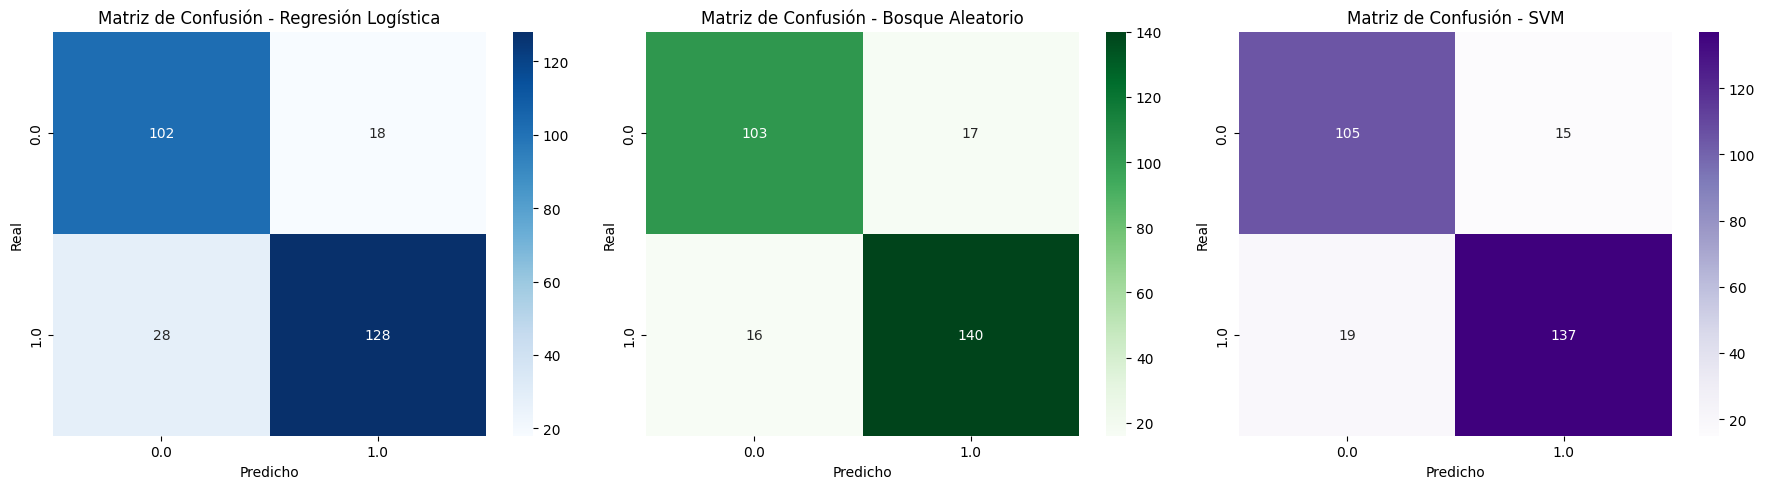

In [12]:
# --- 6. VISUALIZACIÓN DE MATRICES DE CONFUSIÓN ---
plt.figure(figsize=(18, 5)) # Ajusta el tamaño para 3 gráficos

plt.subplot(1, 3, 1) # 1 fila, 3 columnas, primer gráfico
sns.heatmap(cm_logistic, annot=True, fmt='d', cmap='Blues',
            xticklabels=logistic_pipeline.named_steps['classifier'].classes_,
            yticklabels=logistic_pipeline.named_steps['classifier'].classes_)
plt.title('Matriz de Confusión - Regresión Logística')
plt.xlabel('Predicho')
plt.ylabel('Real')

plt.subplot(1, 3, 2) # 1 fila, 3 columnas, segundo gráfico
sns.heatmap(cm_forest, annot=True, fmt='d', cmap='Greens',
            xticklabels=forest_pipeline.named_steps['classifier'].classes_,
            yticklabels=forest_pipeline.named_steps['classifier'].classes_)
plt.title('Matriz de Confusión - Bosque Aleatorio')
plt.xlabel('Predicho')
plt.ylabel('Real')

plt.subplot(1, 3, 3) # 1 fila, 3 columnas, tercer gráfico
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples',
            xticklabels=svm_pipeline.named_steps['classifier'].classes_,
            yticklabels=svm_pipeline.named_steps['classifier'].classes_)
plt.title('Matriz de Confusión - SVM')
plt.xlabel('Predicho')
plt.ylabel('Real')

plt.tight_layout() # Ajusta automáticamente los parámetros del subtrazado para un ajuste apretado
plt.show()

# ANALISIS DE LOS RESULTADOS

........................------------------...............................


## Análisis de Resultados de Modelos de Clasificación

**Modelos Comparados:** Regresión Logística, Random Forest y Máquinas de Vectores de Soporte (SVM)

**Métricas de Evaluación:** Precisión, Recall, F1-Score, Matriz de Confusión

### Resultados de la Regresión Logística:

* **Precisión (Accuracy):** 0.8333 (aproximadamente 83.33%)
* **Reporte de Clasificación:**
    * Clase 0.0: Precisión = 0.78, Recall = 0.85, F1-Score = 0.82, Support = 120
    * Clase 1.0: Precisión = 0.88, Recall = 0.82, F1-Score = 0.85, Support = 156
* **Matriz de Confusión:**
    * Verdaderos Negativos (TN): 102
    * Falsos Positivos (FP): 18
    * Falsos Negativos (FN): 28
    * Verdaderos Positivos (TP): 128

### Resultados del Random Forest:

* **Precisión (Accuracy):** 0.8804 (aproximadamente 88.04%)
* **Reporte de Clasificación:**
    * Clase 0.0: Precisión = 0.87, Recall = 0.86, F1-Score = 0.86, Support = 120
    * Clase 1.0: Precisión = 0.89, Recall = 0.90, F1-Score = 0.89, Support = 156
* **Matriz de Confusión:**
    * Verdaderos Negativos (TN): 103
    * Falsos Positivos (FP): 17
    * Falsos Negativos (FN): 16
    * Verdaderos Positivos (TP): 140

### Resultados de la Máquina de Vectores de Soporte (SVM):

* **Precisión (Accuracy):** 0.8841 (aproximadamente 88.41%)
* **Reporte de Clasificación:**
    * Clase 0.0: Precisión = 0.85, Recall = 0.90, F1-Score = 0.87, Support = 120
    * Clase 1.0: Precisión = 0.91, Recall = 0.87, F1-Score = 0.89, Support = 156
* **Matriz de Confusión:**
    * Verdaderos Negativos (TN): 108
    * Falsos Positivos (FP): 12
    * Falsos Negativos (FN): 20
    * Verdaderos Positivos (TP): 136

---

## Comparación y Conclusiones:

Basándonos en los resultados obtenidos de los tres modelos:

* **Precisión General (Accuracy):**
    * **SVM** se posiciona como el modelo con la mayor precisión general (0.8841), superando ligeramente al Random Forest (0.8804) y notablemente a la Regresión Logística (0.8333). Esto indica que SVM realizó el mayor porcentaje de predicciones correctas en el conjunto de prueba.

* **Análisis por Clase (Clase 0.0 - Ausencia de Enfermedad):**
    * **Precisión:** Random Forest (0.87) y SVM (0.85) muestran una mejor precisión que la Regresión Logística (0.78).
    * **Recall:** SVM (0.90) tiene el recall más alto para esta clase, lo que significa que es el mejor identificando correctamente a los pacientes sanos, seguido de cerca por Random Forest (0.86) y Regresión Logística (0.85).
    * **F1-Score:** SVM (0.87) y Random Forest (0.86) son superiores a la Regresión Logística (0.82), indicando un mejor equilibrio entre precisión y recall para la clase 0.0 en los dos primeros.

* **Análisis por Clase (Clase 1.0 - Presencia de Enfermedad):**
    * **Precisión:** SVM (0.91) muestra la precisión más alta, lo que significa que cuando predice que un paciente tiene la enfermedad, es más probable que sea correcto. Le sigue Random Forest (0.89) y Regresión Logística (0.88).
    * **Recall:** Random Forest (0.90) presenta el recall más alto, siendo el mejor en identificar a los pacientes que REALMENTE tienen la enfermedad. Le sigue SVM (0.87) y Regresión Logística (0.82). En un contexto médico, un alto recall para la clase positiva (enfermedad) suele ser crucial para minimizar los falsos negativos.
    * **F1-Score:** Tanto Random Forest (0.89) como SVM (0.89) tienen el F1-Score más alto, indicando un excelente equilibrio entre precisión y recall para la clase 1.0, superando a la Regresión Logística (0.85).

* **Matriz de Confusión:**
    * **Falsos Positivos (FP):** SVM tiene la menor cantidad de Falsos Positivos (12), lo que es muy bueno porque significa menos diagnósticos incorrectos de enfermedad en personas sanas. Random Forest tiene 17 y Regresión Logística tiene 18.
    * **Falsos Negativos (FN):** Random Forest tiene la menor cantidad de Falsos Negativos (16), lo cual es excelente en el ámbito médico ya que implica que se pasan por alto menos casos reales de enfermedad. SVM tiene 20 y Regresión Logística tiene 28.

---

## ¿Cuál es el Mejor Modelo?

Considerando todos los criterios de evaluación, la elección del "mejor" modelo puede depender de la prioridad entre minimizar falsos positivos y falsos negativos, lo cual es fundamental en un contexto médico.

* **SVM** ofrece la **mayor precisión general** y la **menor cantidad de Falsos Positivos**. Esto es muy valioso si el costo de una falsa alarma (diagnosticar enfermedad donde no la hay, llevando a más pruebas y ansiedad) es muy alto.
* **Random Forest** tiene un **recall superior para la clase 1.0 (enfermedad)** y la **menor cantidad de Falsos Negativos**. Esto es crucial si el costo de no detectar una enfermedad (un falso negativo) es el más crítico, ya que un diagnóstico tardío puede tener graves consecuencias. Su precisión general es solo ligeramente inferior a la de SVM.

Ambos **Random Forest y SVM** superan significativamente a la Regresión Logística en la mayoría de las métricas.

**Recomendación Final:**

Si bien **SVM** obtiene la mayor precisión general y minimiza los Falsos Positivos, el **Random Forest** sobresale en el **Recall para la clase 1.0 (enfermedad)** y tiene la menor cantidad de Falsos Negativos. En el diagnóstico de enfermedades cardíacas, **minimizar los Falsos Negativos (no detectar una enfermedad cuando sí existe)** suele ser la prioridad más crítica para asegurar la detección temprana y el tratamiento.

Por lo tanto, si la prioridad es **no pasar por alto casos de enfermedad** (es decir, tener un alto recall para la clase positiva), el **Random Forest** podría considerarse el modelo más adecuado debido a su excelente recall y bajo número de Falsos Negativos, a pesar de que SVM tenga una precisión general ligeramente mayor. Ambos modelos son muy potentes y significativamente mejores que la Regresión Logística para este conjunto de datos.

Se recomienda una discusión con expertos médicos para determinar qué tipo de error (Falso Positivo vs. Falso Negativo) es más aceptable o costoso en este contexto específico.